# 22 — GNN-SDM Production Training

Train GNN-SDM for all qualifying species using the best architecture
from notebook 20. Compare results with the RF baseline.

Uses shared modules: `gnn_model.py`, `data_utils.py`.

### Setup and load graph

In [1]:
import config
import numpy as np
import pandas as pd
import pickle
import json
import time
import torch
import torch.nn.functional as F
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from gnn_model import GNNSDM, train_gnn_species
from data_utils import load_species_patches, load_patch_data

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Load graph
with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

# Load patch features
patch_features, patch_counts, feature_names = load_patch_data()
n_patches = patch_features.shape[0]
n_features = len(feature_names)
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges, '
      f'{n_features} features')


/home/marco/Dokumente/Projekte/cas-aml-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Patches: 166,464, features: 12
Graph: 166,464 nodes, 465,833 edges, 12 features


In [2]:
import os
os.environ["AWS_PROFILE"] = "dataplatform-dev"

In [3]:
species_patches, species_counts = load_species_patches(config, min_records=100)


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7fd702625ee0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7fd70385aba0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7fd6f8672a50>, 8736.871594631)])']
connector: <aiohttp.connector.TCPConnector object at 0x7fd6f0ea2cf0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7fd6f05dede0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7fd6f8672f30>, 8736.977495547)])']
connector: <aiohttp.connector.TCPConnector object at 0x7fd6fc93d2e0>


GBIF records: 22,723,973
Species with >= 100 records: 3,756


### Model and training function

Imported from `gnn_model.py` (shared across notebooks 20, 21, 22).

In [4]:
# Model and train function imported above from gnn_model.py
print(f'GNNSDM architecture test: {GNNSDM(n_features, [64, 48, 32])}')
print(f'Parameters: {sum(p.numel() for p in GNNSDM(n_features, [64, 48, 32]).parameters()):,}')


GNNSDM architecture test: GNNSDM(
  (convs): ModuleList(
    (0): SAGEConv(12, 64, aggr=mean)
    (1): SAGEConv(64, 48, aggr=mean)
    (2): SAGEConv(48, 32, aggr=mean)
  )
  (out): Linear(in_features=32, out_features=1, bias=True)
)
Parameters: 10,929


### Set architecture from notebook 20 results

In [5]:
# Best architecture from notebook 20 (architecture search)
best_hidden_dims = [64, 48, 32]
EPOCHS = 500
PATIENCE = 50

print(f'Architecture: {best_hidden_dims}')
print(f'Max epochs: {EPOCHS}, patience: {PATIENCE}')


Architecture: [64, 48, 32]
Max epochs: 500, patience: 50


### Convert to PyG and compute PageRank

In [6]:
# Node features
X = torch.tensor(patch_features, dtype=torch.float32)
X_mean = X.mean(dim=0)
X_std = X.std(dim=0).clamp(min=1e-6)
X = (X - X_mean) / X_std

# Edge index
edges = list(G.edges())
src = [e[0] for e in edges] + [e[1] for e in edges]
dst = [e[1] for e in edges] + [e[0] for e in edges]
edge_index = torch.tensor([src, dst], dtype=torch.long)

# PageRank
print('Computing PageRank...')
pagerank = nx.pagerank(G)
pr_values = torch.tensor([pagerank[i] for i in range(n_patches)], dtype=torch.float32)

# Move to device
X_gpu = X.to(device)
edge_index_gpu = edge_index.to(device)

print(f'X: {X_gpu.shape}, edge_index: {edge_index_gpu.shape}, device: {device}')


Computing PageRank...
X: torch.Size([166464, 12]), edge_index: torch.Size([2, 931666]), device: cuda


### Train for all species

In [7]:
import os
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, cohen_kappa_score,
)

CHECKPOINT_FILE = 'gnn_sdm_checkpoint.csv'
CHECKPOINT_EVERY = 50

# Resume from checkpoint
if os.path.exists(CHECKPOINT_FILE):
    done_df = pd.read_csv(CHECKPOINT_FILE)
    results = done_df.to_dict('records')
    done_species = set(done_df['species'])
    print(f'Resuming: {len(done_species)} done')
else:
    results = []
    done_species = set()

species_list = [sp for sp in species_patches if sp not in done_species]
print(f'Training GNN-SDM for {len(species_list)} species '
      f'(max {EPOCHS} epochs, patience {PATIENCE})...')
t0 = time.time()

for i, sp in enumerate(species_list):
    presence = species_patches[sp]
    if len(presence) < 5:
        continue

    suitability, val_auc = train_gnn_species(
        sp, presence, X_gpu, edge_index_gpu,
        pr_values, n_patches, device,
        hidden_dims=best_hidden_dims, epochs=EPOCHS, patience=PATIENCE,
    )

    # Evaluate
    pres_arr = np.array(list(presence))
    absence = np.setdiff1d(np.arange(n_patches), pres_arr)
    rng = np.random.default_rng(42)
    abs_sample = rng.choice(absence, min(len(absence), len(pres_arr) * 3), replace=False)

    eval_idx = np.concatenate([pres_arr, abs_sample])
    y_true = np.concatenate([np.ones(len(pres_arr)), np.zeros(len(abs_sample))])
    y_score = suitability[eval_idx]
    y_pred = (y_score >= 0.5).astype(int)

    results.append({
        'species': sp,
        'n_records': int(species_counts[sp]),
        'n_presence_patches': len(pres_arr),
        'val_auc': val_auc,
        'auc_mean': roc_auc_score(y_true, y_score),
        'accuracy_mean': accuracy_score(y_true, y_pred),
        'precision_mean': precision_score(y_true, y_pred, zero_division=0),
        'recall_mean': recall_score(y_true, y_pred),
        'f1_mean': f1_score(y_true, y_pred),
        'mcc_mean': matthews_corrcoef(y_true, y_pred),
        'kappa_mean': cohen_kappa_score(y_true, y_pred),
        'tss_mean': recall_score(y_true, y_pred) + recall_score(y_true, y_pred, pos_label=0) - 1,
    })

    if (i + 1) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (len(species_list) - i - 1)
        print(f'  {i+1}/{len(species_list)}  '
              f'elapsed={elapsed:.0f}s  ETA={eta:.0f}s  '
              f'last AUC={results[-1]["auc_mean"]:.3f}')

pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
elapsed = time.time() - t0
print(f'\nDone: {len(results)} species in {elapsed:.0f}s ({elapsed/60:.1f} min)')


Resuming: 3751 done
Training GNN-SDM for 5 species (max 500 epochs, patience 50)...

Done: 3751 species in 0s (0.0 min)


### Results and comparison with RF baseline

Species in both: 3751

--- Mean metrics ---
Metric              RF       GNN         Δ
----------------------------------------
auc              0.838     0.704    -0.134
accuracy         0.812     0.475    -0.338
precision        0.715     0.323    -0.392
recall           0.395     0.841    +0.446
f1               0.489     0.432    -0.056
mcc              0.428     0.210    -0.218
kappa            0.395     0.134    -0.262
tss              0.346     0.194    -0.153


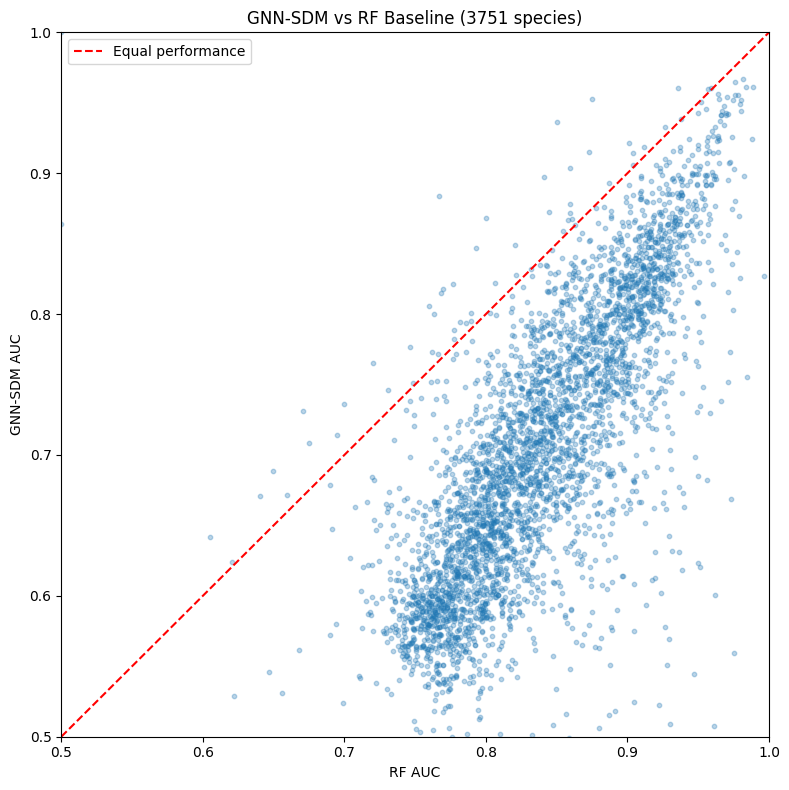


GNN better than RF: 57/3751 (1.5%)
Saved gnn_sdm_results.csv


In [8]:
import matplotlib.pyplot as plt

gnn_df = pd.DataFrame(results)

# Load RF baseline
rf_df = pd.read_csv('baseline_rf_results.csv')

# Merge on species
comp = gnn_df.merge(rf_df, on='species', suffixes=('_gnn', '_rf'))
print(f'Species in both: {len(comp)}')

metrics = ['auc', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'kappa', 'tss']

print('\n--- Mean metrics ---')
print(f'{"Metric":12s}  {"RF":>8s}  {"GNN":>8s}  {"Δ":>8s}')
print('-' * 40)
for m in metrics:
    rf_col = f'{m}_mean_rf'
    gnn_col = f'{m}_mean_gnn'
    if rf_col in comp.columns and gnn_col in comp.columns:
        rf_val = comp[rf_col].mean()
        gnn_val = comp[gnn_col].mean()
        print(f'{m:12s}  {rf_val:8.3f}  {gnn_val:8.3f}  {gnn_val - rf_val:+8.3f}')

# Scatter: GNN AUC vs RF AUC
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comp['auc_mean_rf'], comp['auc_mean_gnn'], alpha=0.3, s=10)
ax.plot([0.5, 1], [0.5, 1], 'r--', label='Equal performance')
ax.set_xlabel('RF AUC')
ax.set_ylabel('GNN-SDM AUC')
ax.set_title(f'GNN-SDM vs RF Baseline ({len(comp)} species)')
ax.legend()
ax.set_xlim(0.5, 1)
ax.set_ylim(0.5, 1)
plt.tight_layout()
plt.show()

# How many species improved?
improved = (comp['auc_mean_gnn'] > comp['auc_mean_rf']).sum()
print(f'\nGNN better than RF: {improved}/{len(comp)} '
      f'({improved/len(comp)*100:.1f}%)')

gnn_df.to_csv('gnn_sdm_results.csv', index=False)
print('Saved gnn_sdm_results.csv')
